# OrthoFinder Live Tutorial: Orthogroups, Orthologs, and Gene Trees

**Team:** Alex Tocco, Caroline Pita, Isaac Rubio  
**Course project tool:** OrthoFinder 3.1.4  
**Dataset:** four *Mycoplasma* proteomes from the official OrthoFinder example data

## 1. Tool Background: What OrthoFinder Does

OrthoFinder is a comparative genomics program that starts with protein FASTA files and infers evolutionary relationships among genes across species.

The main outputs are orthogroups, orthologs, paralogs, gene trees, a species tree, and gene duplication statistics.

OrthoFinder was developed by David M. Emms and Steven Kelly. The original 2015 paper introduced OrthoFinder as a way to reduce major biases in whole genome orthogroup inference. The 2019 paper expanded OrthoFinder into a phylogenetic orthology inference tool. The current OrthoFinder 3 series adds faster and more complete workflows, including hierarchical orthogroups.

## 2. Biological Uses

OrthoFinder is used for genome scale comparative biology. Researchers use it to analyze protein coding genes from bacteria, fungi, plants, animals, and broad evolutionary datasets.

Typical questions include: Which genes are conserved? Which gene families expanded? Which genes are one to one orthologs? Where did duplication events happen? How does gene content compare among related genomes?

Our example uses four *Mycoplasma* species. The biological goal is to see how OrthoFinder turns raw proteomes into orthogroups, ortholog relationships, gene duplication events, and a rooted species tree.

## 3. Installation and Verification

For this tutorial, we use the conda environment **of3_env**, which contains OrthoFinder 3.1.4.

Installation commands:

    conda create -n of3_env python=3.12
    conda activate of3_env
    conda install -c bioconda -c conda-forge orthofinder pandas matplotlib ipykernel
    python -m ipykernel install --user --name of3_env --display-name "OrthoFinder 3.1.4 (of3_env)"
    orthofinder -v

In Jupyter, the kernel for this notebook should be **OrthoFinder 3.1.4 (of3_env)**.

In [1]:
from pathlib import Path
import os
import subprocess
import pandas as pd
import matplotlib.pyplot as plt

start = Path.cwd().resolve()
candidates = [start, *start.parents, start / "Course_Project_OrthoFinder"]
PROJECT = None
for candidate in candidates:
    if (candidate / "final_results" / "orthofinder_run" / "Results_May11").exists():
        PROJECT = candidate
        break
if PROJECT is None:
    raise FileNotFoundError("Could not find final_results/orthofinder_run/Results_May11. Open this notebook from Course_Project_OrthoFinder or Team_team.")

DATA_DIR = PROJECT / "final_demo_input"
RESULTS = PROJECT / "final_results" / "orthofinder_run" / "Results_May11"
FIGURES = PROJECT / "figures"
FIGURES.mkdir(exist_ok=True)

print("Project folder:", PROJECT)
print("Input FASTA folder:", DATA_DIR)
print("OrthoFinder results:", RESULTS)

Project folder: /Users/carolinepita/Documents/GitHub/CompStatBioeng/Team_team/Course_Project_OrthoFinder
Input FASTA folder: /Users/carolinepita/Documents/GitHub/CompStatBioeng/Team_team/Course_Project_OrthoFinder/final_demo_input
OrthoFinder results: /Users/carolinepita/Documents/GitHub/CompStatBioeng/Team_team/Course_Project_OrthoFinder/final_results/orthofinder_run/Results_May11


In [ ]:
# Verify that we are using the OrthoFinder 3 environment.
env = os.environ.copy()
env["PATH"] = "/Users/carolinepita/miniconda3/envs/of3_env/bin:" + env.get("PATH", "")

orthofinder_version = subprocess.run(["orthofinder", "-v"], env=env, capture_output=True, text=True, check=True)
diamond_version = subprocess.run(["diamond", "version"], env=env, capture_output=True, text=True, check=True)

print(orthofinder_version.stdout.strip())
print(diamond_version.stdout.strip())

OrthoFinder:v3.1.4
diamond version 2.1.25


## 4. Computational Theory

OrthoFinder combines sequence similarity, clustering, and phylogenetic interpretation.

First, it compares all input proteins against each other using a fast sequence search program, here DIAMOND. Second, it normalizes similarity scores to reduce gene length and evolutionary distance biases. Third, it builds a graph where genes are nodes and similarity relationships are weighted edges, then clusters that graph using MCL.

After orthogroup inference, OrthoFinder aligns genes in orthogroups, infers gene trees, infers a species tree, roots the tree using duplication information, and reconciles gene trees with the species tree. This lets it distinguish orthologs from paralogs.

## 5. Input Data

The input is one protein FASTA file per species. Each file contains predicted protein coding genes for that species.

In [3]:
def count_fasta_records(path):
    with open(path) as handle:
        return sum(1 for line in handle if line.startswith(">"))

fasta_files = sorted(DATA_DIR.glob("*.faa"))
fasta_summary = pd.DataFrame({
    "species": [p.stem for p in fasta_files],
    "protein_sequences": [count_fasta_records(p) for p in fasta_files],
    "file": [p.name for p in fasta_files]
})
display(fasta_summary)

,species,protein_sequences,file
0,Mycoplasma_agalactiae,820,Mycoplasma_agalactiae.faa
1,Mycoplasma_gallisepticum,763,Mycoplasma_gallisepticum.faa
2,Mycoplasma_genitalium,476,Mycoplasma_genitalium.faa
3,Mycoplasma_hyopneumoniae,674,Mycoplasma_hyopneumoniae.faa


## 6. Running OrthoFinder

The completed analysis was run with this command:

    conda activate of3_env
    orthofinder -f final_demo_input -t 4 -o final_results/orthofinder_run

In [4]:
required_files = [
    RESULTS / "Comparative_Genomics_Statistics" / "Statistics_Overall.tsv",
    RESULTS / "Comparative_Genomics_Statistics" / "Statistics_PerSpecies.tsv",
    RESULTS / "Orthogroups" / "Orthogroups.GeneCount.tsv",
    RESULTS / "Gene_Duplication_Events" / "Duplications.tsv",
    RESULTS / "Species_Tree" / "SpeciesTree_rooted.txt",
]
for file in required_files:
    print(("FOUND   " if file.exists() else "MISSING ") + str(file.relative_to(PROJECT)))
if not all(file.exists() for file in required_files):
    raise FileNotFoundError("A required OrthoFinder result file is missing.")

FOUND   final_results/orthofinder_run/Results_May11/Comparative_Genomics_Statistics/Statistics_Overall.tsv
FOUND   final_results/orthofinder_run/Results_May11/Comparative_Genomics_Statistics/Statistics_PerSpecies.tsv
FOUND   final_results/orthofinder_run/Results_May11/Orthogroups/Orthogroups.GeneCount.tsv
FOUND   final_results/orthofinder_run/Results_May11/Gene_Duplication_Events/Duplications.tsv
FOUND   final_results/orthofinder_run/Results_May11/Species_Tree/SpeciesTree_rooted.txt


## 7. Result 1: Overall Run Quality

The first quality control question is whether most genes were assigned to orthogroups. If many genes are unassigned, the input species may be too distantly related, annotations may be poor, or species sampling may be too sparse.

In [31]:
overall_path = RESULTS / "Comparative_Genomics_Statistics" / "Statistics_Overall.tsv"
rows = []
with open(overall_path) as handle:
    for line in handle:
        parts = line.rstrip("\n").split("\t")
        if len(parts) != 2 or not parts[0]:
            break
        rows.append(parts)
overall = pd.DataFrame(rows, columns=["Statistic", "Value"])
display(overall)

summary = dict(rows)
print(f"OrthoFinder assigned {summary['Number of genes in orthogroups']} of {summary['Number of genes']} genes ({summary['Percentage of genes in orthogroups']}%) to {summary['Number of orthogroups']} orthogroups.")

,Statistic,Value
0,Number of species,4
1,Number of genes,2733
2,Number of genes in orthogroups,2216
3,Number of unassigned genes,517
4,Percentage of genes in orthogroups,81.1
5,Percentage of unassigned genes,18.9
6,Number of orthogroups,599
7,Number of species-specific orthogroups,84
8,Number of genes in species-specific orthogroups,379
9,Percentage of genes in species-specific orthog...,13.9


OrthoFinder assigned 2216 of 2733 genes (81.1%) to 599 orthogroups.


## 8. Result 2: Per-Species Assignment

This table shows whether any one species performed much worse than the others. In this run, all four species have most genes assigned to orthogroups, with the lowest values around 78-79%.

,Mycoplasma_agalactiae,Mycoplasma_gallisepticum,Mycoplasma_genitalium,Mycoplasma_hyopneumoniae
Number of genes,820,763,476,674
Number of genes in orthogroups,650,597,417,552
Number of unassigned genes,170,166,59,122
Percentage of genes in orthogroups,79.3,78.2,87.6,81.9
Percentage of unassigned genes,20.7,21.8,12.4,18.1
Number of orthogroups containing species,458,457,388,442
Percentage of orthogroups containing species,76.5,76.3,64.8,73.8
Number of species-specific orthogroups,37,11,3,33
Number of genes in species-specific orthogroups,171,95,6,107
Percentage of genes in species-specific orthogroups,20.9,12.5,1.3,15.9


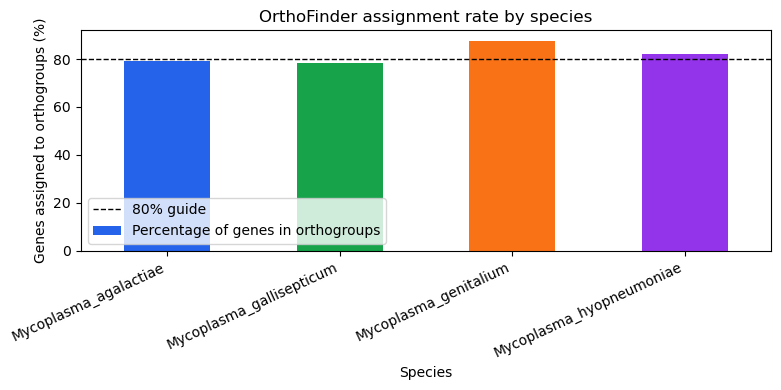

Saved: figures/final_per_species_assignment.png


In [6]:
per_species_path = RESULTS / "Comparative_Genomics_Statistics" / "Statistics_PerSpecies.tsv"
per_species = pd.read_csv(per_species_path, sep="	", index_col=0, nrows=11)
display(per_species)

pct = per_species.loc["Percentage of genes in orthogroups"].astype(float)
ax = pct.plot(kind="bar", figsize=(8, 4), color=["#2563eb", "#16a34a", "#f97316", "#9333ea"])
ax.set_ylabel("Genes assigned to orthogroups (%)")
ax.set_xlabel("Species")
ax.set_title("OrthoFinder assignment rate by species")
ax.axhline(80, color="black", linestyle="--", linewidth=1, label="80% guide")
ax.legend()
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
out = FIGURES / "final_per_species_assignment.png"
plt.savefig(out, dpi=200)
plt.show()
print("Saved:", out.relative_to(PROJECT))

## 9. Result 3: Orthogroup Sizes

Orthogroups are ordered from largest to smallest. The largest orthogroups in this small dataset are species specific expansions, especially in *Mycoplasma gallisepticum* and *Mycoplasma agalactiae*.

,Orthogroup,Mycoplasma_agalactiae,Mycoplasma_gallisepticum,Mycoplasma_genitalium,Mycoplasma_hyopneumoniae,Total
0,OG0000000,0,58,0,0,58
1,OG0000001,51,0,0,0,51
2,OG0000002,3,10,0,3,16
3,OG0000003,15,0,0,0,15
4,OG0000004,1,1,0,12,14
5,OG0000005,10,0,0,3,13
6,OG0000006,1,8,3,1,13
7,OG0000007,0,13,0,0,13
8,OG0000008,0,7,0,5,12
9,OG0000009,5,2,3,1,11


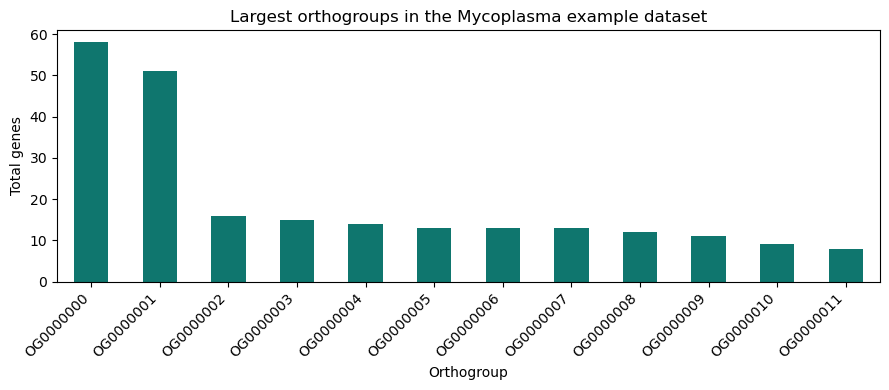

Saved: figures/final_largest_orthogroups.png


In [7]:
gene_count_path = RESULTS / "Orthogroups" / "Orthogroups.GeneCount.tsv"
gene_counts = pd.read_csv(gene_count_path, sep="	")
display(gene_counts.head(12))

ax = gene_counts.head(12).plot(x="Orthogroup", y="Total", kind="bar", figsize=(9, 4), legend=False, color="#0f766e")
ax.set_ylabel("Total genes")
ax.set_xlabel("Orthogroup")
ax.set_title("Largest orthogroups in the Mycoplasma example dataset")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
out = FIGURES / "final_largest_orthogroups.png"
plt.savefig(out, dpi=200)
plt.show()
print("Saved:", out.relative_to(PROJECT))

## 10. Result 4: Pairwise Orthologs

OrthoFinder reports pairwise ortholog tables. These are useful when we want to ask: for a gene in one species, what are the corresponding genes in another species?

In [8]:
pairwise_path = RESULTS / "Orthologues" / "Orthologues_Mycoplasma_hyopneumoniae" / "Mycoplasma_hyopneumoniae__v__Mycoplasma_agalactiae.tsv"
orthologs = pd.read_csv(pairwise_path, sep="	")
print("Pairwise table:", pairwise_path.relative_to(PROJECT))
display(orthologs.head(10))
print(f"This file contains {len(orthologs)} orthogroup rows linking M. hyopneumoniae and M. agalactiae genes.")

Pairwise table: final_results/orthofinder_run/Results_May11/Orthologues/Orthologues_Mycoplasma_hyopneumoniae/Mycoplasma_hyopneumoniae__v__Mycoplasma_agalactiae.tsv


,Orthogroup,Mycoplasma_hyopneumoniae,Mycoplasma_agalactiae
0,OG0000002,"gi|144227629|gb|AAZ44523.2|, gi|144227727|gb|A...","gi|290752565|emb|CBH40537.1|, gi|290752539|emb..."
1,OG0000004,"gi|71851859|gb|AAZ44467.1|, gi|144227552|gb|AA...",gi|290752424|emb|CBH40395.1|
2,OG0000005,"gi|144227449|gb|AAZ44155.2|, gi|71852131|gb|AA...","gi|290752910|emb|CBH40885.1|, gi|290752905|emb..."
3,OG0000005,gi|144227678|gb|AAZ44609.2|,gi|290752911|emb|CBH40886.1|
4,OG0000006,gi|71851550|gb|AAZ44158.1|,gi|290753066|emb|CBH41042.1|
5,OG0000009,gi|144227478|gb|AAZ44221.2|,"gi|290752414|emb|CBH40385.1|, gi|290752490|emb..."
6,OG0000011,gi|71852105|gb|AAZ44713.1|,gi|290752593|emb|CBH40565.1|
7,OG0000013,gi|144227627|gb|AAZ44519.2|,"gi|290752822|emb|CBH40797.1|, gi|290752964|emb..."
8,OG0000013,gi|71851952|gb|AAZ44560.1|,gi|290752442|emb|CBH40413.1|
9,OG0000014,gi|71851854|gb|AAZ44462.1|,"gi|290752976|emb|CBH40952.1|, gi|290752482|emb..."


This file contains 338 orthogroup rows linking M. hyopneumoniae and M. agalactiae genes.


## 11. Result 5: Gene Duplication Events

Because OrthoFinder infers gene trees, it can also identify duplication events and map them onto the species tree. Terminal duplications occur on a branch leading to one species; non-terminal duplications occur deeper in the species tree.

,Orthogroup,Species Tree Node,Support,Type
0,OG0000000,Mycoplasma_gallisepticum,1.0,Terminal
1,OG0000000,Mycoplasma_gallisepticum,1.0,Terminal
2,OG0000000,Mycoplasma_gallisepticum,1.0,Terminal
3,OG0000000,Mycoplasma_gallisepticum,1.0,Terminal
4,OG0000000,Mycoplasma_gallisepticum,1.0,Terminal
5,OG0000000,Mycoplasma_gallisepticum,1.0,Terminal
6,OG0000000,Mycoplasma_gallisepticum,1.0,Terminal
7,OG0000000,Mycoplasma_gallisepticum,1.0,Terminal
8,OG0000000,Mycoplasma_gallisepticum,1.0,Terminal
9,OG0000000,Mycoplasma_gallisepticum,1.0,Terminal


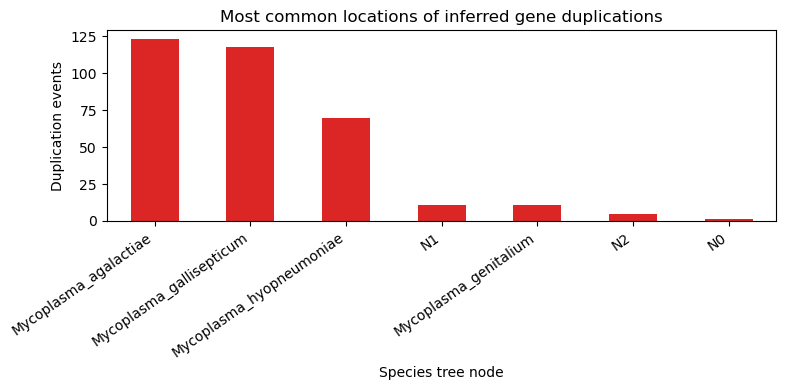

Saved: figures/final_duplication_counts.png


In [10]:
dup_path = RESULTS / "Gene_Duplication_Events" / "Duplications.tsv"
dups = pd.read_csv(dup_path, sep="	")
compact_dups = dups[["Orthogroup", "Species Tree Node", "Support", "Type"]].copy()
display(compact_dups.head(12))

node_counts = dups["Species Tree Node"].value_counts().head(10)
ax = node_counts.plot(kind="bar", figsize=(8, 4), color="#dc2626")
ax.set_ylabel("Duplication events")
ax.set_xlabel("Species tree node")
ax.set_title("Most common locations of inferred gene duplications")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
out = FIGURES / "final_duplication_counts.png"
plt.savefig(out, dpi=200)
plt.show()
print("Saved:", out.relative_to(PROJECT))

## 12. Result 6: Species Tree for the Simple Four Species Dataset

This first species tree is intentionally simple. It is useful for teaching what a rooted species tree is, because there are only four tips and two clear sister species pairs.

In [11]:
tree_path = RESULTS / "Species_Tree" / "SpeciesTree_rooted.txt"
newick = tree_path.read_text().strip()
print("Rooted species tree in Newick format:")
print(newick)
print("\nInterpretation: ((M. gallisepticum, M. genitalium), (M. hyopneumoniae, M. agalactiae))")

Rooted species tree in Newick format:
((Mycoplasma_gallisepticum:0.447071,Mycoplasma_genitalium:0.531161)1:0.256168,(Mycoplasma_hyopneumoniae:0.539988,Mycoplasma_agalactiae:0.509358)1:0.256168);

Interpretation: ((M. gallisepticum, M. genitalium), (M. hyopneumoniae, M. agalactiae))


## 12.1 Species Tree Figure

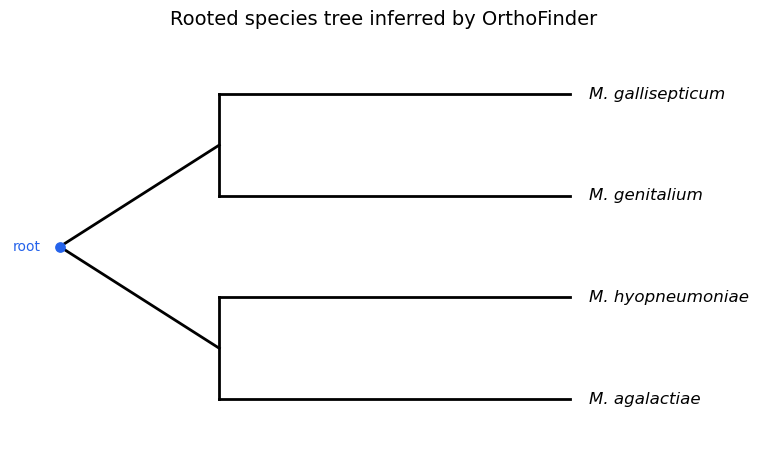

Saved: figures/final_species_tree.png


In [30]:
# Topology from SpeciesTree_rooted.txt:
# ((M. gallisepticum, M. genitalium), (M. hyopneumoniae, M. agalactiae));

fig, ax = plt.subplots(figsize=(8, 4.8))

# y positions for tips
ys = {
    "M. gallisepticum": 3,
    "M. genitalium": 2,
    "M. hyopneumoniae": 1,
    "M. agalactiae": 0,
}

# x positions chosen from the rooted tree branch lengths, scaled for readability
root_x = 0.0
internal_x = 0.256
right_x = 0.82

left_pair_y = (ys["M. gallisepticum"] + ys["M. genitalium"]) / 2
right_pair_y = (ys["M. hyopneumoniae"] + ys["M. agalactiae"]) / 2
root_y = (left_pair_y + right_pair_y) / 2

# root to internal nodes
ax.plot([root_x, internal_x], [root_y, left_pair_y], color="black", lw=2)
ax.plot([root_x, internal_x], [root_y, right_pair_y], color="black", lw=2)

# vertical connectors within each pair
ax.plot([internal_x, internal_x], [ys["M. genitalium"], ys["M. gallisepticum"]], color="black", lw=2)
ax.plot([internal_x, internal_x], [ys["M. agalactiae"], ys["M. hyopneumoniae"]], color="black", lw=2)

# terminal branches
for label in ["M. gallisepticum", "M. genitalium", "M. hyopneumoniae", "M. agalactiae"]:
    ax.plot([internal_x, right_x], [ys[label], ys[label]], color="black", lw=2)
    ax.text(right_x + 0.03, ys[label], label, va="center", fontsize=12, style="italic")

ax.scatter([root_x], [root_y], color="#2563eb", s=45, zorder=3)
ax.text(root_x - 0.03, root_y, "root", ha="right", va="center", fontsize=10, color="#2563eb")

ax.set_title("Rooted species tree inferred by OrthoFinder", fontsize=14)
ax.set_xlim(-0.08, 1.12)
ax.set_ylim(-0.6, 3.6)
ax.axis("off")
plt.tight_layout()

out = FIGURES / "final_species_tree.png"
plt.savefig(out, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", out.relative_to(PROJECT))

## 13. Six Species Extension

The four species dataset is best for the live beginner tutorial. To show more of OrthoFinder's comparative power, we also ran a second dataset with two additional *Mycoplasma* proteomes already included with the example data: *M. arthritidis* and *M. haemocanis*.

This richer dataset is still small enough to run quickly, but it gives a more interesting tree and more informative orthogroup statistics.

In [29]:
RESULTS_6 = PROJECT / "final_results_6species" / "orthofinder_run" / "Results_May11"
DATA_6 = PROJECT / "final_demo_input_6species"

required_6 = [
    RESULTS_6 / "Comparative_Genomics_Statistics" / "Statistics_Overall.tsv",
    RESULTS_6 / "Comparative_Genomics_Statistics" / "Statistics_PerSpecies.tsv",
    RESULTS_6 / "Orthogroups" / "Orthogroups.GeneCount.tsv",
    RESULTS_6 / "Species_Tree" / "SpeciesTree_rooted.txt",
]
for file in required_6:
    print(("FOUND   " if file.exists() else "MISSING ") + str(file.relative_to(PROJECT)))
if not all(file.exists() for file in required_6):
    raise FileNotFoundError("A required six species OrthoFinder result file is missing.")

FOUND   final_results_6species/orthofinder_run/Results_May11/Comparative_Genomics_Statistics/Statistics_Overall.tsv
FOUND   final_results_6species/orthofinder_run/Results_May11/Comparative_Genomics_Statistics/Statistics_PerSpecies.tsv
FOUND   final_results_6species/orthofinder_run/Results_May11/Orthogroups/Orthogroups.GeneCount.tsv
FOUND   final_results_6species/orthofinder_run/Results_May11/Species_Tree/SpeciesTree_rooted.txt


In [32]:
six_rows = []
with open(RESULTS_6 / "Comparative_Genomics_Statistics" / "Statistics_Overall.tsv") as handle:
    for line in handle:
        parts = line.rstrip("\n").split("\t")
        if len(parts) != 2 or not parts[0]:
            break
        six_rows.append(parts)
six_overall = pd.DataFrame(six_rows, columns=["Statistic", "Value"])
display(six_overall)

six_summary = dict(six_rows)
print(f"OrthoFinder assigned {six_summary['Number of genes in orthogroups']} of {six_summary['Number of genes']} genes ({six_summary['Percentage of genes in orthogroups']}%) to {six_summary['Number of orthogroups']} orthogroups.")

,Statistic,Value
0,Number of species,6
1,Number of genes,4481
2,Number of genes in orthogroups,3783
3,Number of unassigned genes,698
4,Percentage of genes in orthogroups,84.4
5,Percentage of unassigned genes,15.6
6,Number of orthogroups,686
7,Number of species-specific orthogroups,129
8,Number of genes in species-specific orthogroups,1177
9,Percentage of genes in species-specific orthog...,26.3


OrthoFinder assigned 3783 of 4481 genes (84.4%) to 686 orthogroups.


,M_arthritidis,M_haemocanis,Mycoplasma_agalactiae,Mycoplasma_gallisepticum,Mycoplasma_genitalium,Mycoplasma_hyopneumoniae
Number of genes,618,1130,820,763,476,674
Number of genes in orthogroups,499,1023,675,605,421,560
Number of unassigned genes,119,107,145,158,55,114
Percentage of genes in orthogroups,80.7,90.5,82.3,79.3,88.4,83.1
Percentage of unassigned genes,19.3,9.5,17.7,20.7,11.6,16.9
Number of orthogroups containing species,401,279,486,462,390,457
Percentage of orthogroups containing species,58.5,40.7,70.8,67.3,56.9,66.6
Number of species-specific orthogroups,15,34,35,9,3,33
Number of genes in species-specific orthogroups,57,752,165,90,6,107
Percentage of genes in species-specific orthogroups,9.2,66.5,20.1,11.8,1.3,15.9


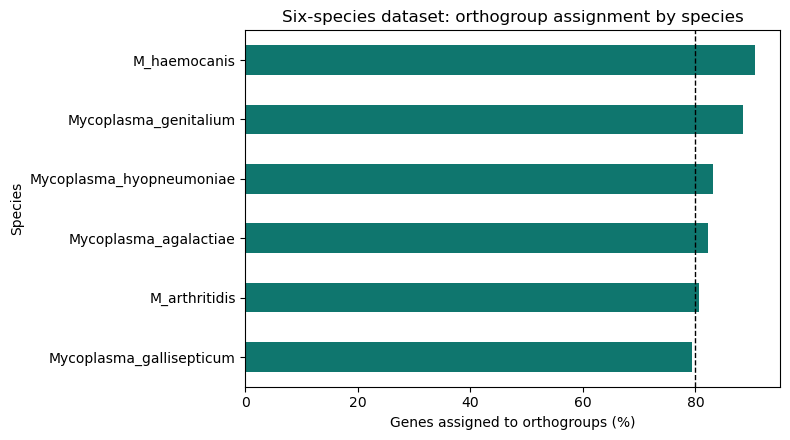

Saved: figures/final_6species_assignment.png


In [17]:
per_species_6 = pd.read_csv(
    RESULTS_6 / "Comparative_Genomics_Statistics" / "Statistics_PerSpecies.tsv",
    sep="\t",
    index_col=0,
    nrows=11,
)
display(per_species_6)

pct6 = per_species_6.loc["Percentage of genes in orthogroups"].astype(float)
ax = pct6.sort_values().plot(kind="barh", figsize=(8, 4.5), color="#0f766e")
ax.set_xlabel("Genes assigned to orthogroups (%)")
ax.set_ylabel("Species")
ax.set_title("Six-species dataset: orthogroup assignment by species")
ax.axvline(80, color="black", linestyle="--", linewidth=1)
plt.tight_layout()
out = FIGURES / "final_6species_assignment.png"
plt.savefig(out, dpi=200)
plt.show()
print("Saved:", out.relative_to(PROJECT))

### Six Species Species Tree

This tree is more useful as a final demonstration because it shows how adding species changes the biological interpretation. It also lets us point out that denser sampling can improve orthogroup inference and give a richer evolutionary context.

![Six-species OrthoFinder species tree](figures/final_species_tree_6species.png)

In [27]:
tree_6 = (RESULTS_6 / "Species_Tree" / "SpeciesTree_rooted.txt").read_text().strip()
print("Six species rooted species tree in Newick format:")
print(tree_6)
print("\nAdding two species increased assignment from 81.1% to 84.4% and produced a more informative tree.")

Six species rooted species tree in Newick format:
(Mycoplasma_hyopneumoniae:0.276261,((M_arthritidis:0.498611,Mycoplasma_agalactiae:0.517029)1:0.104604,((Mycoplasma_genitalium:0.553921,Mycoplasma_gallisepticum:0.471859)1:0.193809,M_haemocanis:0.839973)1:0.406508)1:0.276261);

Adding two species increased assignment from 81.1% to 84.4% and produced a more informative tree.


## 14. What We Learned From Both Datasets

The four species dataset was useful for demonstrating the basic OrthoFinder workflow. Because it was small, it was easier to follow each step: checking the input FASTA files, running OrthoFinder, and looking at the main result files.

The six species dataset helped show what changes when we add more related species. With four species, OrthoFinder assigned 81.1% of genes to orthogroups. With six species, this increased to 84.4%. The number of orthogroups also increased from 599 to 686.

This comparison shows that species sampling can affect the results. Adding more related species gives OrthoFinder more evolutionary context, which can help it recover more gene relationships and produce a more informative species tree.

## 15. How To Use OrthoFinder Outputs

After OrthoFinder runs, the output folder contains many files, but a few are especially useful for beginners.

The overall statistics file tells us whether the run worked well across the full dataset. The per-species statistics file shows whether any individual species had unusually low assignment to orthogroups. The orthogroup tables show which genes are grouped together across species. The ortholog files let us compare genes between pairs of species. The duplication file shows inferred gene duplication events, and the species tree gives an evolutionary summary of the input species.

So in practice, a good beginner workflow is to first check the statistics, then look at orthogroups and orthologs, and finally interpret the species tree and duplication results.

## 16. Strengths, Weaknesses, and Open Questions

One major strength of OrthoFinder is that it is straightforward to run. The input is simple: one protein FASTA file per species. From that, OrthoFinder produces many useful comparative genomics outputs.

Another strength is that OrthoFinder uses evolutionary context. It does not only group genes based on sequence similarity; it also uses gene trees and a species tree to help infer orthologs and duplication events.

A weakness is that the results depend on the quality of the input data. If the protein annotations are incomplete or inaccurate, the results may also be affected. Species sampling also matters, as we saw in the comparison between the four mspecies and six species datasets.

An open question for users is how many species should be included for a strong analysis. Another question is when users should change default settings, such as the sequence search method or tree inference method.

## 17. Conclusion

In this tutorial, we showed how to use OrthoFinder to analyze protein FASTA files from multiple species. We used a simple four species dataset to walk through the main steps, then added two more species to show how the analysis becomes more informative with richer sampling.

Overall, OrthoFinder is useful because it connects sequence data to evolutionary interpretation. It helps identify orthogroups, orthologs, gene duplications, and species relationships.

The biggest takeaway is that OrthoFinder is not just a tool for grouping similar genes. It uses evolutionary information to help interpret gene relationships across species. This makes it useful for studying gene family evolution and comparing genomes.

## Bibliography

Emms, D. M. and Kelly, S. (2015). OrthoFinder: solving fundamental biases in whole genome comparisons dramatically improves orthogroup inference accuracy. *Genome Biology*, 16, 157. https://doi.org/10.1186/s13059-015-0721-2

Emms, D. M. and Kelly, S. (2019). OrthoFinder: phylogenetic orthology inference for comparative genomics. *Genome Biology*, 20, 238. https://doi.org/10.1186/s13059-019-1832-y

Emms, D. M., Liu, Y., Belcher, L., Holmes, J. and Kelly, S. (2025). OrthoFinder3. bioRxiv. https://doi.org/10.1101/2025.07.15.664860

Emms, D. M. and Kelly, S. (2022). SHOOT: phylogenetic gene search and ortholog inference. *Genome Biology*, 23, 85. https://doi.org/10.1186/s13059-022-02652-8

OrthoFinder documentation: https://orthofinder.github.io/OrthoFinder/

OrthoFinder GitHub repository: https://github.com/OrthoFinder/OrthoFinder